In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

repo_root = Path.cwd().resolve()
for candidate in [repo_root, repo_root.parent, repo_root.parent.parent]:
    if (candidate / 'scripts' / 'SemiSupervVAE.py').exists():
        repo_root = candidate
        break
else:
    raise FileNotFoundError('No se encontró scripts/SemiSupervVAE.py desde el directorio actual.')

sys.path.append(str(repo_root / 'scripts'))

from SemiSupervVAE import GPUBatches, SemiSupervVAE, set_seed

plt.style.use('default')
pd.set_option('display.max_columns', 50)

In [7]:
def evaluate_regression(y_true, y_pred, label, threshold=0.05):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    r2 = 1.0 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)

    delta_z = (y_pred - y_true) / (1 + y_true)
    bias = delta_z.mean()
    std_dz = delta_z.std()
    sigma_mad = 1.4826 * np.median(np.abs(delta_z - np.median(delta_z)))
    eta = (np.abs(delta_z) > threshold).mean() * 100

    print(f'--- {label} ---')
    print(f'MAE:       {mae:.5f}')
    print(f'MSE:       {mse:.5f}')
    print(f'RMSE:      {rmse:.5f}')
    print(f'R2:        {r2:.5f}')
    print(f'bias(dz):  {bias:.5f}')
    print(f'std(dz):   {std_dz:.5f}')
    print(f'sigma_MAD: {sigma_mad:.5f}')
    print(f'eta [%]:   {eta:.3f}')
    print()

    return {
        'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2,
        'bias': bias, 'std_dz': std_dz, 'sigma_MAD': sigma_mad, 'eta': eta,
    }


def plot_specz_vs_photoz(z_true, z_pred, threshold=0.05, title=None, ax=None):
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))

    ax.scatter(z_true, z_pred, alpha=0.35, s=7)

    lo = min(z_true.min(), z_pred.min())
    hi = max(z_true.max(), z_pred.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=2, label='1:1')

    z_line = np.linspace(lo, hi, 200)
    ax.plot(z_line, z_line + threshold * (1 + z_line), color='red', lw=2, label=f'Limite catastrofico (|dz| > {threshold})')
    ax.plot(z_line, z_line - threshold * (1 + z_line), color='red', lw=2)

    delta_z = (z_pred - z_true) / (1 + z_true)
    eta = float((np.abs(delta_z) > threshold).mean() * 100.0)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Redshift espectroscopico')
    ax.set_ylabel('Redshift fotometrico predicho')
    if title:
        ax.set_title(title)
    ax.text(0.05, 0.95, f'eta = {eta:.3f}%', transform=ax.transAxes, va='top', ha='left', fontsize=9, bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.8, edgecolor='none'))
    ax.legend(loc='best', fontsize=8)
    return ax, eta

In [8]:
set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_path = repo_root / 'file_out_data' / 'checkpoints' / 'semi_superv_vae_best3.pt'
data_path = repo_root / 'file_out_data' / 'vae_input.npz'

if not checkpoint_path.exists():
    raise FileNotFoundError(f'No se encontró el checkpoint: {checkpoint_path}')
if not data_path.exists():
    raise FileNotFoundError(f'No se encontró el archivo de datos: {data_path}')

checkpoint = torch.load(checkpoint_path, map_location=device)
config = dict(checkpoint['config'])
config['data_path'] = str(data_path)

data = np.load(data_path, allow_pickle=True)
X = data['X']
z = np.asarray(data['z'], dtype=np.float32)
idx_train = np.asarray(data['idx_train'])
idx_test = np.asarray(data['idx_test'])

z_mean = float(z[idx_train].mean())
z_std = float(z[idx_train].std()) if float(z[idx_train].std()) > 0 else 1.0
z_test_raw = z[idx_test].astype(np.float32)
z_test_norm = ((z_test_raw - z_mean) / z_std).astype(np.float32)

X_test = torch.as_tensor(X[idx_test], dtype=torch.float32).to(device)
z_test_tensor = torch.as_tensor(z_test_norm, dtype=torch.float32).unsqueeze(1).to(device)
test_loader = GPUBatches(X_test, z_test_tensor, config['batch_size'], device, shuffle=False)

print(f'device: {device}')
print(f'checkpoint: {checkpoint_path.name}')
print(f'test size: {len(idx_test)}')
print(f'z mean/std train: {z_mean:.6f} / {z_std:.6f}')

device: cuda
checkpoint: semi_superv_vae_best3.pt
test size: 2129
z mean/std train: 0.550021 / 0.394276


In [9]:
model = SemiSupervVAE(config).to(device)
model.load_state_dict(checkpoint['model'])
model.eval()

z_true_raw_batches = []
z_pred_raw_batches = []
recon_batches = []
input_batches = []

with torch.no_grad():
    for x_batch, z_batch, _ in test_loader:
        recon, _, _, z_sup = model(x_batch)
        z_pred_raw = (z_sup.squeeze(1).detach().cpu().numpy() * z_std) + z_mean
        z_true_raw = (z_batch.squeeze(1).detach().cpu().numpy() * z_std) + z_mean
        z_true_raw_batches.append(z_true_raw)
        z_pred_raw_batches.append(z_pred_raw)
        recon_batches.append(recon.detach().cpu())
        input_batches.append(x_batch.detach().cpu())

z_true_raw = np.concatenate(z_true_raw_batches, axis=0)
z_pred_raw = np.concatenate(z_pred_raw_batches, axis=0)
recon_test = torch.cat(recon_batches, dim=0)
input_test = torch.cat(input_batches, dim=0)

metrics = evaluate_regression(z_true_raw, z_pred_raw, 'SemiSupervVAE3 test')
metrics_df = pd.DataFrame([metrics])
metrics_df

--- SemiSupervVAE3 test ---
MAE:       0.09900
MSE:       0.02639
RMSE:      0.16246
R2:        0.82595
bias(dz):  0.01475
std(dz):   0.10933
sigma_MAD: 0.06093
eta [%]:   42.743



,MAE,MSE,RMSE,R2,bias,std_dz,sigma_MAD,eta
0,0.098997,0.026394,0.162464,0.825953,0.014747,0.109325,0.060932,42.743072


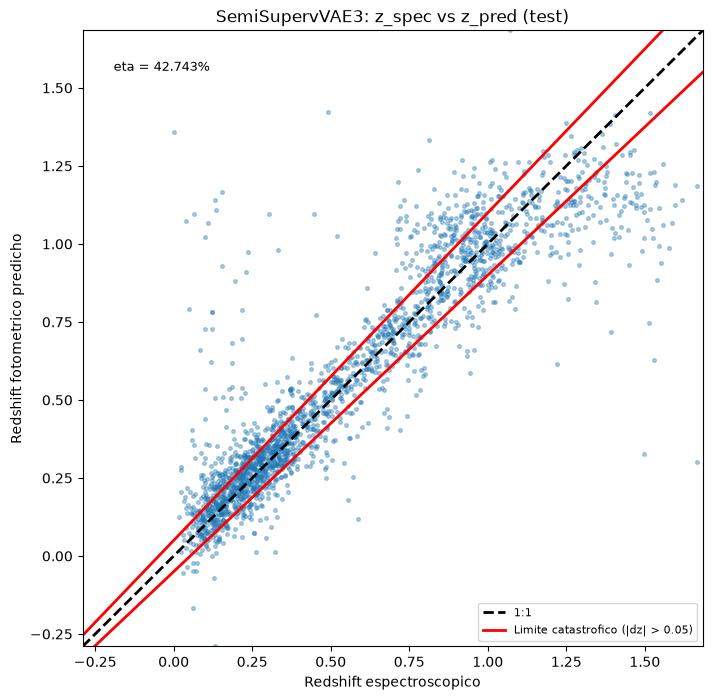

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_specz_vs_photoz(
    z_true_raw,
    z_pred_raw,
    title='SemiSupervVAE3: z_spec vs z_pred (test)',
    ax=ax,
)
plt.show()

$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{recon}} + \beta \cdot \mathcal{L}_{\text{KL}} + \gamma \cdot \mathcal{L}_{z_\text{regression}}    
$$

In [ ]:
# 